### Train Route Analysis Project
#### Journey Time Prediction using Machine Learning

import pandas as pd

In [4]:
import os
print(os.getcwd())

C:\Users\Rohith


## Data loading

In [ ]:
# Load dataset
df = pd.read_csv("Dataset1.csv")

# 1. First rows
print("First 5 rows:\n", df.head())

# 2. Shape
print("\nShape:", df.shape)

# 3. Columns
print("\nColumns:\n", df.columns)

# 4. Info
print("\nInfo:")
print(df.info())

# 5. Missing values
print("\nMissing values;\n", df.isnull().sum())

In [13]:
print("\nStatistics:\n", df.describe())


Statistics:
                   SN       Train_No             1A             2A  \
count  186074.000000  186074.000000  186074.000000  186074.000000   
mean       13.914695   42157.747455    1506.769189    1225.415351   
std        12.779368   25090.080221    2418.719821    1934.975856   
min         1.000000     107.000000     100.000000     100.000000   
25%         5.000000   17225.000000     215.000000     192.000000   
50%        11.000000   40050.000000     465.000000     392.000000   
75%        18.000000   57550.000000    1555.000000    1264.000000   
max       118.000000   99908.000000   21400.000000   17140.000000   

                  3A             SL  Route_Number       Distance  
count  186074.000000  186074.000000      186074.0  186074.000000  
mean      944.061513     662.735777           1.0     281.353838  
std      1451.231892     967.524012           0.0     483.743964  
min       100.000000     100.000000           1.0       0.000000  
25%       169.000000     146.

In [18]:
print("\nDistance Stats:")
print("Mean:", df['Distance'].mean())
print("Median:", df['Distance'].median())
print("Range:", df['Distance'].max() - df['Distance'].min())


Distance Stats:
Mean: 281.3538377204768
Median: 73.0
Range: 4260


In [19]:
routes = df.groupby('Train_No')['Station_Name'].agg(['first', 'last']).reset_index()
routes.columns = ['Train_No', 'Source_station', 'Destination_station']

print("\nRoutes:\n", routes.head())


Routes:
    Train_No Source_station Destination_station
0       107   SAWANTWADI R         MADGOAN JN.
1       108    MADGOAN JN.        SAWANTWADI R
2       128    MADGOAN JN.         CHHATRAPATI
3       290   DELHI-SAFDAR        DELHI-SAFDAR
4       401     AURANGABAD        VARANASI JN.


In [20]:
print("\nDuplicate rows;", df.duplicated().sum())


Duplicate rows; 0


## Data cleaning

In [24]:
# Remove duplicates
df = df.drop_duplicates()

# Convert time columns
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], errors='coerce')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce')

# Fill missing times
df['Arrival_time'] = df['Arrival_time'].ffill()
df['Departure_Time'] = df['Departure_Time'].ffill()

print(df.head())

   SN  Train_No Station_Code   1A   2A   3A   SL  Station_Name  Route_Number  \
0   1       107          SWV  100  100  100  100  SAWANTWADI R             1   
1   2       107         THVM  260  228  196  164        THIVIM             1   
2   3       107         KRMI  345  296  247  198       KARMALI             1   
3   4       107          MAO  490  412  334  256   MADGOAN JN.             1   
4   1       108          MAO  100  100  100  100   MADGOAN JN.             1   

         Arrival_time      Departure_Time  Distance  
0 2026-03-29 00:00:00 2026-03-29 10:25:00         0  
1 2026-03-29 11:06:00 2026-03-29 11:08:00        32  
2 2026-03-29 11:28:00 2026-03-29 11:30:00        49  
3 2026-03-29 12:10:00 2026-03-29 00:00:00        78  
4 2026-03-29 00:00:00 2026-03-29 20:30:00         0  


## Feature Engineering

In [9]:
import numpy as np

# Sort data
df = df.sort_values(by=['Train_No', 'SN'])

# Convert to datetime again (force)
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], errors='coerce')
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], errors='coerce')

# Get start and end time per train
journey = df.groupby('Train_No').agg({
    'Departure_Time': 'first',
    'Arrival_time': 'last',
    'Distance': 'max'
}).reset_index()


# Create duration
journey['Journey_Duration'] = (
    journey['Arrival_time'] - journey['Departure_Time']
).dt.total_seconds() / 60


# Fix negative durations (overnight trains)
journey['Journey_Duration'] = np.where(
    journey['Arrival_time'] < journey['Departure_Time'],
    (journey['Arrival_time'] + pd.Timedelta(days=1) - journey['Departure_Time']).dt.total_seconds() / 60,
    (journey['Arrival_time'] - journey['Departure_Time']).dt.total_seconds() / 60
)

print(journey.head())

   Train_No      Departure_Time        Arrival_time  Distance  \
0       107 2026-04-01 10:25:00 2026-04-01 12:10:00        78   
1       108 2026-04-01 20:30:00 2026-04-01 22:25:00        83   
2       128 2026-04-01 19:40:00 2026-04-01 17:45:00       978   
3       290 2026-04-01 18:30:00 2026-04-01 02:30:00      2694   
4       401 2026-04-01 21:30:00 2026-04-01 10:00:00      1618   

   Journey_Duration  
0             105.0  
1             115.0  
2            1325.0  
3             480.0  
4             750.0  


## Visualization

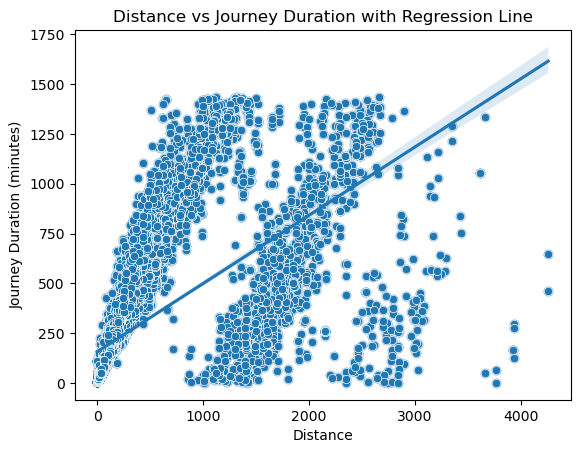

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.regplot(x='Distance', y='Journey_Duration', data=journey)
sns.scatterplot(x = 'Distance', y = 'Journey_Duration', data = journey)

plt.title("Distance vs Journey Duration with Regression Line")
plt.xlabel("Distance")
plt.ylabel("Journey Duration (minutes)")

plt.show()                

In [13]:
print(df['Station_Name'].value_counts().head(10))

Station_Name
CST-MUMBAI      1027
KALYAN JN        828
THANE            796
SEALDAH          745
CHENNAI BEAC     738
HOWRAH JN.       699
DADAR            598
DUM DUM JN.      463
KURLA            462
TAMBARAM         434
Name: count, dtype: int64


## Machine Learning Model

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = journey[['Distance']]
y = journey['Journey_Duration']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


MAE: 168.03564857939355
RMSE: 250.34843911403448
